In [1]:
import re
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import anndata as ad
import scanpy as sc
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from collections import defaultdict
from Bio import SeqIO

In [ ]:
# plot appearance default parameters
mpl.rc('lines', linewidth=0.4)
mpl.rc('font', family="Helvetica", size=8, )
mpl.rc('axes', labelsize=8, titlesize=8, linewidth=0.4)
mpl.rc('legend', fontsize=8)
mpl.rc('xtick', labelsize=8)
mpl.rc('xtick.major', width=0.4, size=2)
mpl.rc('xtick.minor', width=0.4, size=1)
mpl.rc('ytick', labelsize=10)
mpl.rc('ytick.major', width=0.4, size=2)
mpl.rc('ytick.minor', width=0.4, size=1)
mpl.rcParams['pdf.fonttype'] = 42
mpl.font_manager.weight_dict['roman'] = 400

cmap = mpl.cm.get_cmap("YlOrBr") # for all plots

### Data preparation

In [3]:
# raw adata from scRNA-seq
adata_sc =  sc.read_h5ad('../data/scRNAseq.h5ad')
adata_enh = ad.read_h5ad('../data/Enhancers_AnnData.h5ad')

In [4]:
# getting gene names associated with primate specific enhancers
primate_genes = adata_enh.var.loc[adata_enh.var["category"] == "primate_specific", "gene"]
# avoid_genes = ['DNAJB1', 'FBN2', 'HSPA1A', 'HSPA1B', 'PDGFA', 'PEG3', 'ZIM2', 'ZNF460', 'STIP1', 'TGFBR3', 'TNNI2']

target_genes = set()
for genes in primate_genes.dropna():
    for g in str(genes).split(","):
        g = g.strip()
        if g: #not in avoid_genes:
            target_genes.add(g)

target_genes = sorted([gene for gene in target_genes if gene in adata_sc.var_names])

### Expression dot plots

/tmp/ipykernel_1274811/2393642477.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_cluster = mean_expr.groupby('cluster')[target_genes].mean()
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


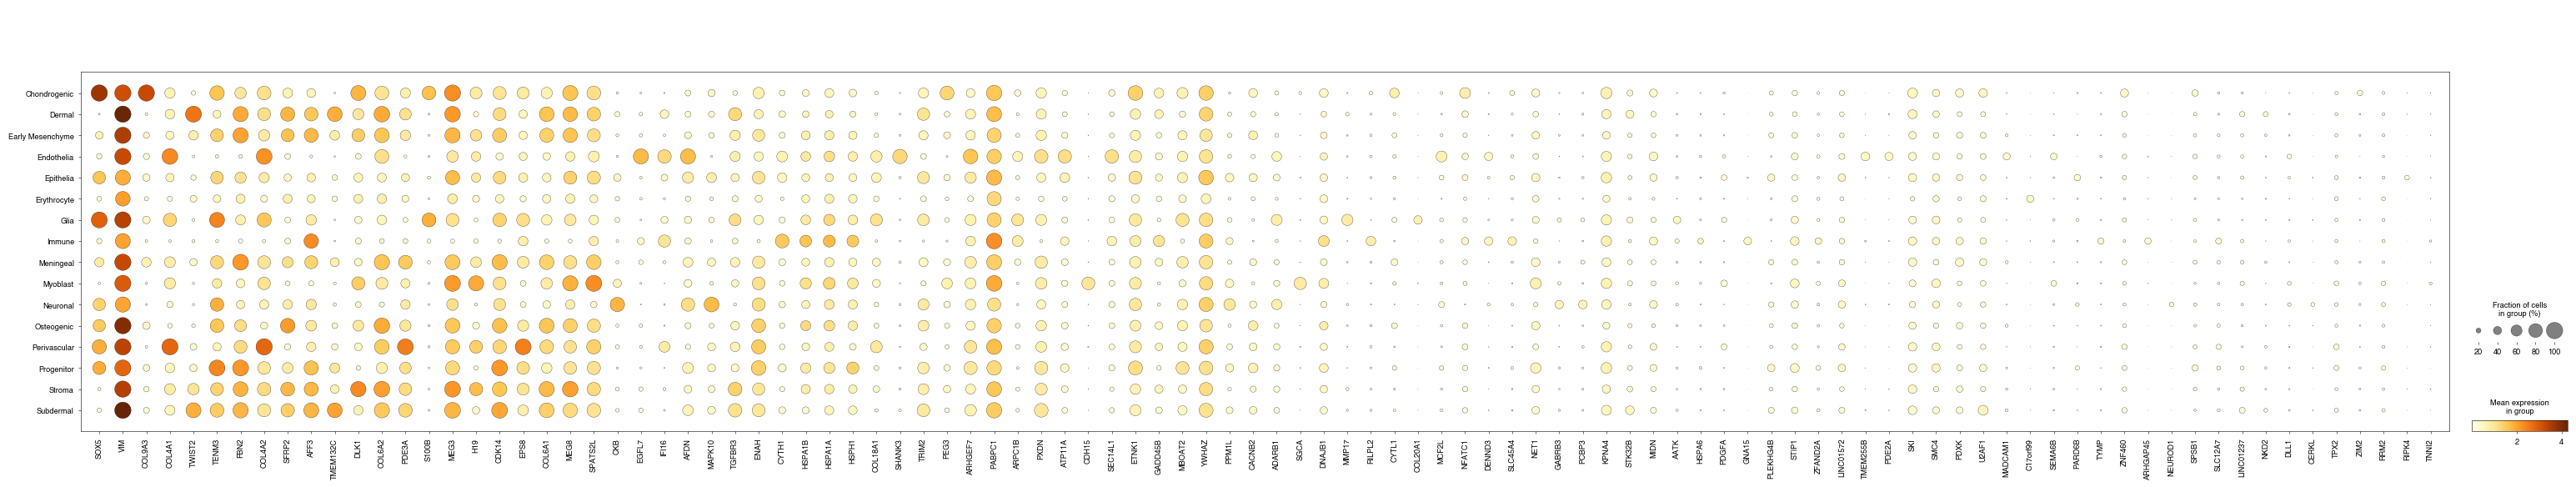

In [7]:
# Global gene set expression
# compute mean expression per cluster for target genes
mean_expr = pd.DataFrame(
    adata_sc[:, target_genes].X.toarray() if hasattr(adata_sc[:, target_genes].X, 'toarray') 
    else np.array(adata_sc[:, target_genes].X),
    columns=target_genes
)
mean_expr['cluster'] = adata_sc.obs['ann_clusters'].values
mean_per_cluster = mean_expr.groupby('cluster')[target_genes].mean()

# rank genes by variance across clusters (high = specific)
gene_variance = mean_per_cluster.var(axis=0)
target_genes_sorted = gene_variance.sort_values(ascending=False).index.tolist()

# plot
dp = sc.pl.dotplot(adata_sc, target_genes_sorted, groupby='ann_clusters',
                   cmap=cmap, show=False, return_fig=True)
dp.savefig('../plots/dotplot_sorted.pdf', bbox_inches='tight', transparent=True)

In [23]:
single_enh_genes = ['CERKL',
 'GABRB3',
 'PXDN',
 'HSPA6',
 'NEUROD1',
 'SLC12A7',
 'TYMP',
 'ZNF460',
 'MADCAM1',
 'KPNA4',
 'ARHGAP45']

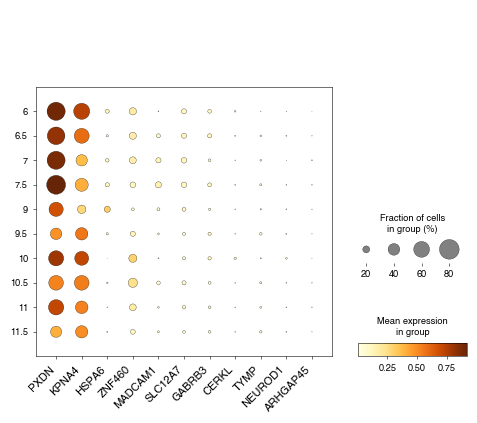

In [16]:
# compute mean expression per cluster for target genes
mean_expr = pd.DataFrame(
    adata_sc[:, single_enh_genes].X.toarray(),
    columns=single_enh_genes
)
mean_expr['cluster'] = adata_sc.obs['Age'].values
mean_per_cluster = mean_expr.groupby('cluster', observed=True)[single_enh_genes].mean()

# rank genes by variance across clusters (high = specific)
gene_variance = mean_per_cluster.var(axis=0)
target_genes_sorted = gene_variance.sort_values(ascending=False).index.tolist()

# plot
dp = sc.pl.dotplot(adata_sc, target_genes_sorted, cmap=cmap, groupby='Age', 
                   # dendrogram=True, 
                   show=False, return_fig=True)

dp.get_axes()['mainplot_ax'].set_xticklabels(
    dp.get_axes()['mainplot_ax'].get_xticklabels(),
    rotation=45, ha='right', fontsize=8
)

fig = dp.get_axes()['mainplot_ax'].get_figure()
# fig.savefig('../plots/single_enh_genes.pdf', bbox_inches='tight', transparent=True)
plt.show()

In [24]:
top_enh_n_genes = ['TWIST2',
 'MEG8',
 'MEG3',
 'COL4A1',
 'COL18A1',
 'MIDN',
 'COL6A2',
 'COL6A1',
 'TMEM132C',
 'MCF2L',
 'S100B',
 'NFATC1',
 'ARHGEF7',
 'U2AF1',
 'ADARB1',
 'ATP11A',
 'TMEM255B',
 'AATK',
 'AFDN',
]

In [25]:
human_specific_enh_genes = [
    'DLC1',
    'SGCZ',
    'PDZRN3',
    'KIF26B',
    'NLRP3'
]

In [11]:
genes_together = top_enh_n_genes + human_specific_enh_genes

/tmp/ipykernel_248859/2336742211.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_cluster = mean_expr.groupby('cluster')[genes_together].mean()


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


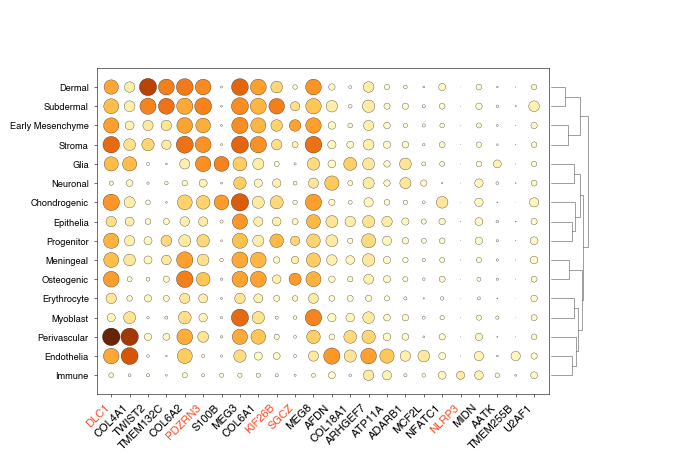

In [14]:
mean_expr = pd.DataFrame(
    adata_sc[:, genes_together].X.toarray(),
    columns=genes_together
)
mean_expr['cluster'] = adata_sc.obs['ann_clusters'].values
mean_per_cluster = mean_expr.groupby('cluster')[genes_together].mean()

# rank genes by variance across clusters (high = specific)
gene_variance = mean_per_cluster.var(axis=0)
target_genes_sorted = gene_variance.sort_values(ascending=False).index.tolist()

# plot
dp = sc.pl.dotplot(adata_sc, target_genes_sorted, cmap=cmap, groupby='ann_clusters',
                var_group_rotation=45, show=False, return_fig=True,
                  dendrogram=True)
dp.show_colorbar = False
dp.show_size_legend = False

# dots sizing
main_ax = dp.get_axes()['mainplot_ax']
for coll in main_ax.collections:
    sizes = coll.get_sizes()
    if len(sizes) > 0:
        coll.set_sizes(sizes * 0.8)

# gene labels
dp.get_axes()['mainplot_ax'].set_xticklabels(
    dp.get_axes()['mainplot_ax'].get_xticklabels(), 
    rotation=45, ha='right', fontsize=8,
    )

main_ax = dp.get_axes()['mainplot_ax']
labels = main_ax.get_xticklabels()
for label in labels:
    gene = label.get_text()
    if gene in human_specific_enh_genes:
        label.set_color('#fc4e2a')


# get the actual matplotlib figure and save that
fig = dp.get_axes()['mainplot_ax'].get_figure()
fig.set_size_inches(7.5, 5)
fig.savefig('../plots/enh_genes_together.pdf', bbox_inches='tight', transparent=True)

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


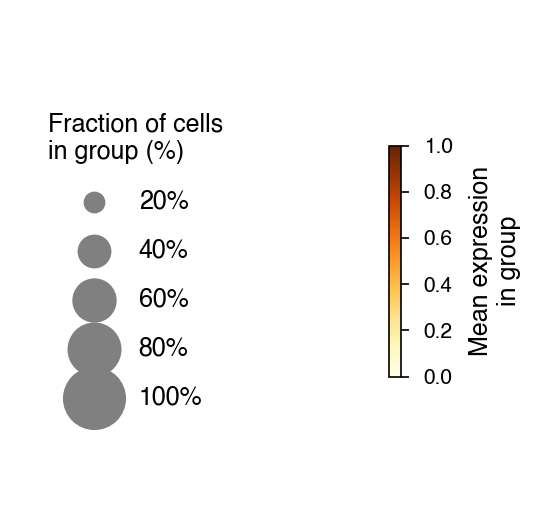

In [ ]:
# legend separately
fig_leg, (ax_size, ax_color) = plt.subplots(1, 2, figsize=(2, 2), dpi=300)
fig_leg.patch.set_alpha(0)

# size legend
ax_size.axis('off')
sizes = [20, 40, 60, 80, 100]
scatter_sizes = [(s / 100) ** dp.size_exponent * dp.largest_dot for s in sizes]
legend_elements = [plt.scatter([], [], s=size, color='gray', label=f'{s}%')
                   for size, s in zip(scatter_sizes, sizes)]
ax_size.legend(handles=legend_elements, title=dp.size_title,
               loc='center', frameon=False, fontsize=6,
               title_fontsize=6, labelspacing=1.0)

# colorbar
ax_color.axis('off')
sm = ScalarMappable(cmap=dp.cmap,
                    norm=Normalize(vmin=dp.vboundnorm.vmin, vmax=dp.vboundnorm.vmax))
sm.set_array([])
cbar = fig_leg.colorbar(sm, ax=ax_color, orientation='vertical', fraction=0.5, pad=0, shrink=0.5)
cbar.set_label(dp.color_legend_title, fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.savefig('../plots/dotplot_legend.pdf', bbox_inches='tight', transparent=True)
plt.show()

In [69]:
collagens = [
    'COL6A1',
    'COL6A2',
    'COL4A1',
    'COL4A2', 
    'COL18A1',
    'COL20A1',
    'COL9A3'
]

/tmp/ipykernel_1994191/3042661167.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_per_cluster = mean_expr.groupby('cluster')[collagens].mean()
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


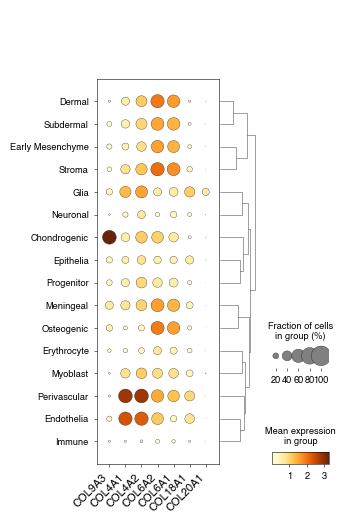

In [31]:
mean_expr = pd.DataFrame(
    adata_sc[:, collagens].X.toarray(),
    columns=collagens
)
mean_expr['cluster'] = adata_sc.obs['ann_clusters'].values
mean_per_cluster = mean_expr.groupby('cluster')[collagens].mean()

# rank genes by variance across clusters (high = specific)
gene_variance = mean_per_cluster.var(axis=0)
target_genes_sorted = gene_variance.sort_values(ascending=False).index.tolist()


# plot
dp = sc.pl.dotplot(adata_sc, target_genes_sorted, cmap=cmap, groupby='ann_clusters', dendrogram=True,
                   # swap_axes=True, 
                   var_group_rotation=45,
                   show=False, return_fig=True)

dp.get_axes()['mainplot_ax'].set_xticklabels(
    dp.get_axes()['mainplot_ax'].get_xticklabels(), 
    rotation=45, ha='right', fontsize=8
)

main_ax = dp.get_axes()['mainplot_ax']
for coll in main_ax.collections:
    sizes = coll.get_sizes()
    if len(sizes) > 0:
        coll.set_sizes(sizes * 0.5)
        
# get the actual matplotlib figure and save that
fig = dp.get_axes()['mainplot_ax'].get_figure()
fig.set_size_inches(3, 5.9)
fig.savefig('../plots/collagens_enh_genes.pdf', bbox_inches='tight', transparent=True)

plt.show()

### Summary of expression for all genes of interest

In [73]:
def gene_expression_summary(
    adata,
    genes, 
    cluster_col_name='ann_clusters'
):
    import numpy as np
    import pandas as pd

    genes = [g for g in genes if g in adata.var_names]
    
    expr = adata[:, genes].to_df()
    expr[cluster_col_name] = adata.obs[cluster_col_name].values

    summary = []

    for gene in genes:
        means = expr.groupby(cluster_col_name, observed=True)[gene].mean()
        
        frac_cells = expr.groupby(cluster_col_name, observed=True)[gene].apply(
            lambda x: (x > 0).mean() * 100
        )

        top_cluster = means.idxmax()
        top_mean = means.loc[top_cluster]
        top_percent = frac_cells.loc[top_cluster]

        background_mean = expr.loc[
            expr[cluster_col_name] != top_cluster, gene
        ].mean()
        
        enrichment = (
            top_mean / background_mean
            if background_mean > 0
            else np.nan
        )

        summary.append({
            "gene": gene,
            "top_cluster": top_cluster,
            "percent_expressing_top_cluster": top_percent,
            "mean_expression_top_cluster": top_mean,
            "background_mean_expression": background_mean,
            "fold_enrichment_vs_background": enrichment
        })

    return pd.DataFrame(summary)

In [76]:
genes_for_summary = set(genes_together + single_enh_genes + collagens)

In [77]:
df_summary = gene_expression_summary(adata_sc, genes_for_summary)

In [78]:
df_summary = df_summary.sort_values('fold_enrichment_vs_background',
ascending=False
)

df_summary

,gene,top_cluster,percent_expressing_top_cluster,mean_expression_top_cluster,background_mean_expression,fold_enrichment_vs_background
11,NLRP3,Immune,35.797190,0.645251,0.003315,194.643326
37,COL20A1,Glia,41.514022,0.671860,0.004932,136.214493
12,NEUROD1,Neuronal,18.513048,0.288362,0.002650,108.803665
2,ARHGAP45,Immune,28.873956,0.293911,0.002915,100.822868
23,TMEM255B,Endothelia,43.185149,0.410577,0.007186,57.137707
20,CERKL,Neuronal,14.771049,0.201100,0.004977,40.404789
5,TYMP,Immune,27.815109,0.333005,0.024888,13.379916
7,GABRB3,Neuronal,40.915805,0.572082,0.047999,11.918668
22,S100B,Glia,80.758632,1.883428,0.163214,11.539608
13,COL9A3,Chondrogenic,99.032223,3.257724,0.294059,11.078453


In [62]:
df_summary.to_excel('../output/2_3_Gene_expression_summary.xlsx')

In [81]:
def one_gene_expression_summary(adata, gene, cluster_col):
    # expression table
    expr = adata[:, gene].to_df()
    expr[cluster_col] = adata.obs[cluster_col].values

    # mean expression per cluster
    means = expr.groupby(cluster_col, observed=True)[gene].mean()

    # percent expressing cells
    frac_cells = expr.groupby(cluster_col, observed=True)[gene].apply(
        lambda x: (x > 0).mean() * 100
    )

    # combine into dataframe
    df = pd.DataFrame({
        'mean_expression': means,
        'percent_expressing_cells': frac_cells
    })

    # sort by expression
    df = df.sort_values(
        'mean_expression',
        ascending=False
    )

    return df

In [ ]:
gene_df = one_gene_expression_summary(adata_sc, 'AFDN', 'ann_clusters')
gene_df

,mean_expression,percent_expressing_cells
ann_clusters,,
Endothelia,1.676105,89.912066
Neuronal,1.167480,76.366322
Epithelia,0.805839,59.491451
Progenitor,0.665668,59.091125
Subdermal,0.611740,56.893617
Meningeal,0.569290,50.538773
Stroma,0.414459,36.812841
Myoblast,0.380197,37.101842
Early Mesenchyme,0.352854,32.212879
